# Double Texting

Seamless handling of [double texting](https://docs.langchain.com/langsmith/double-texting) is important for handling real-world usage scenarios, especially in chat applications.

Users can send multiple messages in a row before the prior run(s) complete, and we want to ensure that we handle this gracefully.

## Reject

A simple approach is to [reject](https://docs.langchain.com/langsmith/reject-concurrent) any new runs until the current run completes.

In [1]:
%%capture --no-stderr
%pip install -U langgraph_sdk

In [2]:
from langgraph_sdk import get_client

url_for_cli_deployment = "http://localhost:8123"
client = get_client(url = url_for_cli_deployment)

In [5]:
import httpx
from langchain_core.messages import HumanMessage

# Create a thread
thread = await client.threads.create()

# Create todo's
user_input_1 = "Add a ToDo to follow-up with DI Repairs."
user_input_2 = "Add a ToDo to mount dresser to the wall."
config = {"configurable": {"user_id": "Test-Double-Texting"}}
graph_name = "task_maistro" 

run = await client.runs.create(
     thread["thread_id"],
    graph_name,
    input={"messages": [HumanMessage(content=user_input_1)]}, 
    config=config,
)

try:
    await client.runs.create(
        thread["thread_id"],
        graph_name,
        input={"messages": [HumanMessage(content=user_input_2)]}, 
        config=config,
        multitask_strategy="reject",
    )
except httpx.HTTPStatusError as e:
    print("Failed to start concurrent run", e)

Failed to start concurrent run Thread is already running a task. Wait for it to finish or choose a different multitask strategy.


In [6]:
from langchain_core.messages import convert_to_messages

# Wait until the original run completes
await client.runs.join(thread["thread_id"], run["run_id"])

# Get the state of the thread
state = await client.threads.get_state(thread["thread_id"])
for m in convert_to_messages(state["values"]["messages"]):
    m.pretty_print()

================================ Human Message =================================

Add a ToDo to follow-up with DI Repairs.
================================== Ai Message ==================================
Tool Calls:
  UpdateMemory (4ejga9xtm)
 Call ID: 4ejga9xtm
  Args:
    update_type: todo
================================= Tool Message =================================

New ToDo created:
Content: {'deadline': '2026-06-20T10:00:00', 'solutions': ['Call DI Repairs', 'Send email to DI Repairs'], 'task': 'Follow-up with DI Repairs', 'time_to_complete': 30}
================================== Ai Message ==================================

I've added a new ToDo to follow-up with DI Repairs. Your ToDo list has been updated.


## Enqueue

We can use [enqueue](https://docs.langchain.com/langsmith/enqueue-concurrent) any new runs until the current run completes.

In [7]:
# Create a new thread 
thread = await client.threads.create()

# Create a new todo's
user_input_1 = "Send Erik his t-shirt gift this weekend."
user_input_2 = "Get cash and pay nanny for 2 weeks. Do this by Friday."
config = {"configurable": {"user_id": "Test-Double-Texting"}}
graph_name = "task_maistro" 

first_run = await client.runs.create(
    thread["thread_id"],
    graph_name,
    input = {"messages": [HumanMessage(content = user_input_1) ]},
)

second_run = await client.runs.create(
    thread["thread_id"],
    graph_name,
    input = {"messages": [HumanMessage(content = user_input_2) ]},
)

# Wait until the second run completes
await client.runs.join(thread["thread_id"], second_run["run_id"])

# Get The state of the thread

state = await client.threads.get_state(thread["thread_id"])

for m in convert_to_messages(state["values"]["messages"]):
    m.pretty_print()

================================ Human Message =================================

Send Erik his t-shirt gift this weekend.
================================== Ai Message ==================================
Tool Calls:
  UpdateMemory (w0ktm7255)
 Call ID: w0ktm7255
  Args:
    update_type: todo
================================= Tool Message =================================

Document 8c87f89e-5258-4934-80d3-15154e7abe31 updated:
Plan: Update the deadline of the task 'Send Erik his t-shirt gift' to this weekend.
Added content: 2026-06-18T23:59:59
================================== Ai Message ==================================

I've updated your ToDo list. The task 'Send Erik his t-shirt gift' is already on your list with a deadline of 2026-06-18T23:59:59, which is this weekend. If you need any help with packing or shipping the gift, don't hesitate to ask.
================================ Human Message =================================

Get cash and pay nanny for 2 weeks. Do this by Friday.

## Interrupt

We can use [interrupt](https://docs.langchain.com/langsmith/interrupt-concurrent) to interrupt the current run, but save all the work that has been done so far up to that point.


In [8]:
import asyncio

# Create a new thread
thread = await client.threads.create()

# Create new ToDos
user_input_1 = "Give me a summary of my ToDos due tomrrow."
user_input_2 = "Never mind, create a ToDo to Order Ham for Thanksgiving by next Friday."
config = {"configurable": {"user_id": "Test-Double-Texting"}}
graph_name = "task_maistro" 

interrupted_run = await client.runs.create(
    thread["thread_id"],
    graph_name,
    input={"messages": [HumanMessage(content=user_input_1)]}, 
    config=config,
)

# Wait for some of run 1 to complete so that we can see it in the thread 
await asyncio.sleep(1)

second_run = await client.runs.create(
    thread["thread_id"],
    graph_name,
    input={"messages": [HumanMessage(content=user_input_2)]}, 
    config=config,
    multitask_strategy="interrupt",
)

# Wait until the second run completes
await client.runs.join(thread["thread_id"], second_run["run_id"])

# Get the state of the thread
state = await client.threads.get_state(thread["thread_id"])
for m in convert_to_messages(state["values"]["messages"]):
    m.pretty_print()

================================ Human Message =================================

Give me a summary of my ToDos due tomrrow.
================================ Human Message =================================

Never mind, create a ToDo to Order Ham for Thanksgiving by next Friday.
================================== Ai Message ==================================
Tool Calls:
  UpdateMemory (eax5t3tbp)
 Call ID: eax5t3tbp
  Args:
    update_type: todo
================================= Tool Message =================================

New ToDo created:
Content: {'deadline': '2026-06-21T10:00:00', 'solutions': ['Call the butcher', 'Order online'], 'task': 'Order Ham for Thanksgiving', 'time_to_complete': 15}
================================== Ai Message ==================================

I've added a new task to your ToDo list: Order Ham for Thanksgiving by next Friday.


We can see the initial run is saved, and has status `interrupted`.

In [9]:
# Confirm that the first run was interrupted
print((await client.runs.get(thread["thread_id"], interrupted_run["run_id"]))["status"])

error


## Rollback

We can use [rollback](https://docs.langchain.com/langsmith/rollback-concurrent) to interrupt the prior run of the graph, delete it, and start a new run with the double-texted input.


In [10]:
# Create a new thread
thread = await client.threads.create()

# Create new ToDos
user_input_1 = "Add a ToDo to call to make appointment at Yoga."
user_input_2 = "Actually, add a ToDo to drop by Yoga in person on Sunday."
config = {"configurable": {"user_id": "Test-Double-Texting"}}
graph_name = "task_maistro" 

rolled_back_run = await client.runs.create(
    thread["thread_id"],
    graph_name,
    input={"messages": [HumanMessage(content=user_input_1)]}, 
    config=config,
)

second_run = await client.runs.create(
    thread["thread_id"],
    graph_name,
    input={"messages": [HumanMessage(content=user_input_2)]}, 
    config=config,
    multitask_strategy="rollback",
)

# Wait until the second run completes
await client.runs.join(thread["thread_id"], second_run["run_id"])

# Get the state of the thread
state = await client.threads.get_state(thread["thread_id"])
for m in convert_to_messages(state["values"]["messages"]):
    m.pretty_print()

================================ Human Message =================================

Actually, add a ToDo to drop by Yoga in person on Sunday.
================================== Ai Message ==================================
Tool Calls:
  UpdateMemory (09gezw0kq)
 Call ID: 09gezw0kq
  Args:
    update_type: todo
================================= Tool Message =================================

New ToDo created:
Content: {'deadline': '2026-06-16T23:59:59', 'solutions': ['Drive to Yoga', 'Take public transportation'], 'task': 'Drop by Yoga in person on Sunday', 'time_to_complete': 60}
================================== Ai Message ==================================

I've added a new task to your ToDo list: Drop by Yoga in person on Sunday.


In [11]:
# Confirm that the original run was deleted
try:
    await client.runs.get(thread["thread_id"], rolled_back_run["run_id"])
except httpx.HTTPStatusError as _:
    print("Original run was correctly deleted")

Original run was correctly deleted


### Summary 

We can see [all the methods summarized](https://docs.langchain.com/langsmith/double-texting):

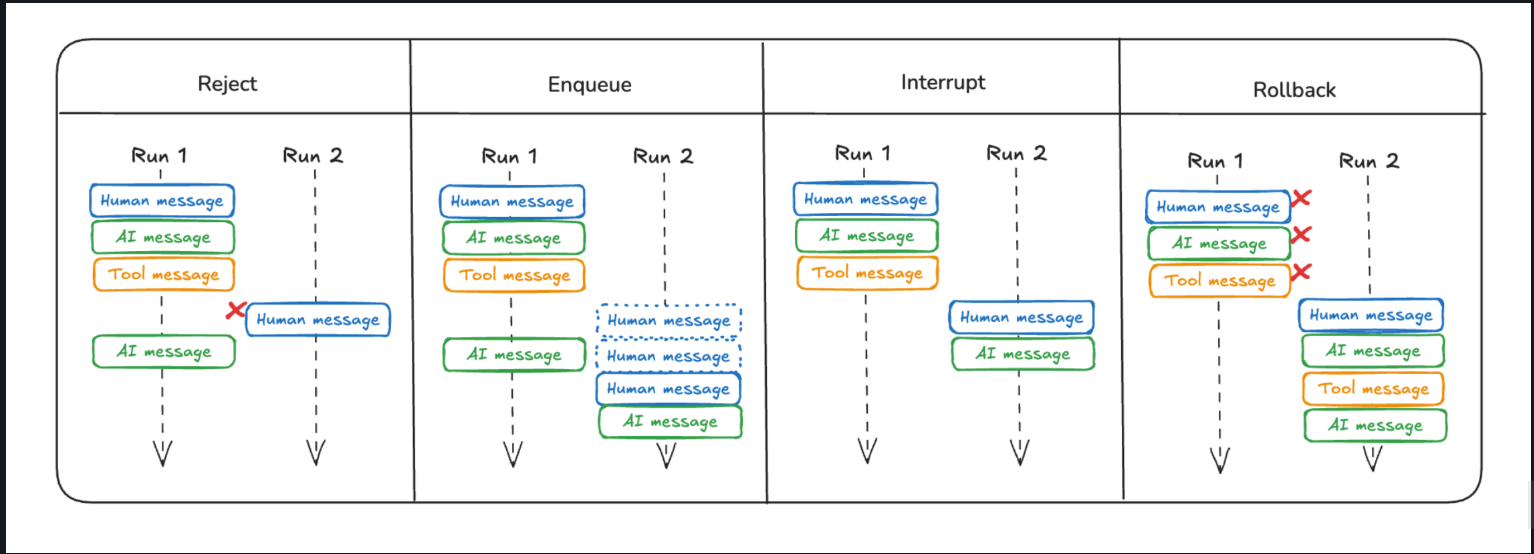